# Example: Let's Build and Test a Trade Bot
In this example, we'll combinae several concepts from the course to build a simple trade bot that can make buy/sell/hold decisions based on moving averages, bandit problems and utility maximization.

> __Learning Objectives__
>
> By the end of this example, students will be able to:
> Three learning objectives go here.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include-tradebot-synthetic.jl")); # include the Include.jl file

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [VLQuantitativeFinancePackage.jl documentation](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl). 

### Data, Models and Constants
Before we implement the trade bot, we need to load up some models and data first. First, let's load the HMM model that we estimated using historical data (2014 - 2024). To start, we specify the `path_to_save_file::String` variable, and then we load the HMM model:

In [2]:
saved_state_dict = let

    # initialize -
    path_to_save_file = joinpath(_PATH_TO_DATA,"HMM-WJ-SPY-N-100-daily-aggregate.jld2");
    saved_state_dict = load(path_to_save_file);
    saved_state_dict; # return the loaded dictionary
end

Dict{String, Any} with 11 entries:
  "risk_free_rate"          => 0.043
  "model"                   => MyHiddenMarkovModel([1, 2, 3, 4, 5, 6, 7, 8, 9, …
  "decode"                  => Dict{Int64, Normal}(5=>Normal{Float64}(μ=-3.3565…
  "encoded_archive_with_ju… => [53 72 … 82 92; 93 82 … 80 5; … ; 14 67 … 87 13;…
  "insampledataset"         => [-0.62754, 0.839626, 0.162992, -0.0111337, 0.257…
  "jump_model"              => MyHiddenMarkovModelWithJumps([1, 2, 3, 4, 5, 6, …
  "encoded_archive"         => [48 29 … 28 33; 42 10 … 10 68; … ; 18 37 … 39 77…
  "number_of_states"        => 100
  "in_sample_decoded_archi… => [0.202562 0.962389 … 1.56531 2.7557; 2.94573 1.6…
  "stationary"              => Categorical{Float64, Vector{Float64}}(…
  "in_sample_decoded_archi… => [0.0753184 -0.675607 … -0.759002 -0.470222; -0.1…

Next, let's load the single index model parameters that we computed in the previous example. We'll store this data in the `sim_model_parameters::Dict{String,NamedTuple}` variable. In addition, we return a few other useful variables, such as the historical market growth rate, the mean and variance of the market growth, etc.

In [3]:
sim_model_parameters,Gₘ,Ḡₘ,Varₘ = let

    # initialize -
    path_to_sim_model_parameters = joinpath(_PATH_TO_DATA,"SIMs-SPY-SP500-01-03-14-to-12-31-24.jld2");
    sim_model_parameters = JLD2.load(path_to_sim_model_parameters);
    parameters = sim_model_parameters["data"]; # return

    Gₘ = sim_model_parameters["Gₘ"]; # Get the past market growth rate 
    Ḡₘ = sim_model_parameters["Ḡₘ"]; # mean of market growth rates
    Varₘ = sim_model_parameters["Varₘ"]; # variance of market growth

    # return -
    parameters,  Gₘ , Ḡₘ, Varₘ;
end;

Let's define some constants and parameters that we will use in this example. See the comment lines next to each variable for a description of its purpose, units, permissible values, etc.

In [4]:
Δt = (1.0 / 252.0); # time step (in years) between trading days (assumes 252 trading days per year)
risk_free_rate = 0.043; # annualized risk-free interest rate (4.3% per year)
λ = 1.0; # risk-aversion parameter
number_of_training_steps = 10000; # number of training steps for the bandit agent
Nₒ = 21; # short-term moving average window size (in days)
N₁ = 63; # long-term moving average window size (in days)
N₂ = 10; # tradbot window size for estimating market factor growth rate (in days)
B = 1000.0; # initial cash balance for the trade bot
offset = Nₒ + N₁; # offset to account for moving average buffer (for price data)
number_of_time_steps = 252 + offset; # number of time steps to simulate (1 year of trading days + buffer for moving averages)
GAIN = 10.0; # gain factor for the trade bot reallocation strategy

### Training Market Data

We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period.

Let's load the dataset by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet).

In [5]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"] # load the original dataset (training)

Dict{String, DataFrame} with 515 entries:
  "DD"   => 2329×8 DataFrame…
  "EMR"  => 2767×8 DataFrame…
  "CTAS" => 2767×8 DataFrame…
  "HSIC" => 2767×8 DataFrame…
  "KIM"  => 2767×8 DataFrame…
  "PLD"  => 2767×8 DataFrame…
  "IEX"  => 2767×8 DataFrame…
  "TPR"  => 1803×8 DataFrame…
  "BAC"  => 2767×8 DataFrame…
  "CBOE" => 2767×8 DataFrame…
  "EXR"  => 2767×8 DataFrame…
  "NCLH" => 2767×8 DataFrame…
  "CVS"  => 2767×8 DataFrame…
  "DRI"  => 2767×8 DataFrame…
  "DTE"  => 2767×8 DataFrame…
  "ZION" => 2767×8 DataFrame…
  "AVY"  => 2767×8 DataFrame…
  "EW"   => 2767×8 DataFrame…
  "EA"   => 2767×8 DataFrame…
  ⋮      => ⋮

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has the maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [6]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # maximum number of trading days in our dataset

Now, iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [7]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # check if ticker has maximum trading days
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers_clean_price_data::Vector{String}` variable:

In [8]:
list_of_tickers_clean_price_data = keys(dataset) |> collect |> sort; # list of tickers in our clean dataset

Now let's get a list of all tickers for which we have single index model parameters:

In [9]:
tickers_that_we_have_sim_data_for = keys(sim_model_parameters) |> collect |> sort;

We need to use only the tickers for which we have both price data and SIM parameters. We'll compute [the intersection of the two lists](https://docs.julialang.org/en/v1/base/collections/#Base.intersect) and store the result in the `list_of_tickers::Vector{String}` variable:

In [10]:
list_of_tickers = intersect(tickers_that_we_have_sim_data_for, list_of_tickers_clean_price_data)

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 ⋮
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

___

## Task 1: Initialize a world model and set up a ticker picker agent
Our first task is to construct models of the bandit agent and the world that this agent samples. We construct [a `MyEpsilonSamplingBanditModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyEpsilonSamplingBanditModel) to hold agent data and [a `MyTickerPickerSIMRiskAwareWorldModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyTickerPickerSIMRiskAwareWorldModel) to represent the world, both using [custom `build(...)` methods](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.build-Tuple{Type{MyTickerPickerSIMRiskAwareWorldModel},%20NamedTuple}).

Specify the list of tickers to examine in the `my_list_of_tickers::Vector{String}` array, and store the number of tickers in the `K::Int64` variable:

In [11]:
my_list_of_tickers, K = let
    
    # my_tickers = ["AAPL", "MSFT", "ADBE", "MRK", "PFE", "JNJ", "MET", "NFLX", "AMD", "MU", "NVDA", "INTC", "MMM",
    #     "UNH", "JPM", "OXY", "TSLA", "PEP", "PG", "UPS", "COST", "TGT", "BAC", "C", "WFC", "KR", "WMT", "GS", "LLY", 
    #     "AMGN", "CVS", "ABT", "MDT", "HON", "CAT", "DE", "LMT", "BA", "XOM", "CVX"];

    my_tickers = ["AAPL", "MSFT"];

    unique!(my_tickers); # ensure uniqueness
    K = length(my_tickers);
    my_tickers, K
end;

__Check__: Are all the tickers in `my_list_of_tickers` present in the `list_of_tickers` variable defined earlier? If not, modify `my_list_of_tickers` accordingly.

In [12]:
let
    
    # check that all tickers are in our dataset
    for ticker ∈ my_list_of_tickers
        if !(ticker ∈ list_of_tickers)
            error("Ticker $ticker is not in the dataset.")
        end
    end
    println("All $(length(my_list_of_tickers)) tickers are valid and present in the dataset.")
end;

All 2 tickers are valid and present in the dataset.


Fill me in later.

In [13]:
initial_share_price_dict = let

    # initialize -
    initial_share_price_dict = Dict{String, Float64}();

    for ticker ∈ my_list_of_tickers
        initial_share_price_dict[ticker] = dataset[ticker][end - (Nₒ + N₁), :open]; # get the initial price
    end

    initial_share_price_dict; # return
end;

Next, construct [a `MyEpsilonSamplingBanditModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyEpsilonSamplingBanditModel), which holds information about the [ε-greedy sampling approach](https://arxiv.org/abs/1707.02038). The [`build(...)` method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.build-Tuple{Type{MyEpsilonSamplingBanditModel},%20NamedTuple}) takes the model type and a [NamedTuple](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple) holding the number of arms `K::Int64`, initial values for the `α::Vector{Int64}` and `β::Vector{Int64}` arrays (success and failure counters for each arm), and the exploration parameter `ϵ::Float64` controlling the exploration fraction. 

We save the model instance to the `bandit_model::MyEpsilonSamplingBanditModel` variable:

In [14]:
bandit_model = build(MyEpsilonSamplingBanditModel, (
    K = K, # number bandit arms
    α = ones(K), # initialize to uniform values
    β = ones(K), # initialize to uniform values
));

### Setup a MyTickerPickerSIMRiskAwareWorldModel instance

Now that we have the bandit model, construct [a `MyTickerPickerSIMRiskAwareWorldModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyTickerPickerSIMRiskAwareWorldModel) holding world data. The `world(...)` function takes the `start::Int64` index, an action $a\in\mathcal{A}$ value, and the `world_model::MyTickerPickerSIMRiskAwareWorldModel` instance, then returns a binary reward $r\in\left\{0,1\right\}$.

> __Reward Structure:__
>
> We compare the risk-adjusted excess growth rate of ticker $i$ against the mean market excess growth rate $\bar{G}_{m}$. If the ticker's risk-adjusted excess growth rate exceeds the market benchmark, we assign a reward of 1 (success); otherwise, we assign a reward of 0 (failure). The risk-adjustment factor is $\beta_{i}^{\lambda}$, where $\beta$ is the ticker's beta coefficient from the single index model, and $\lambda\in\mathbb{R}_{\geq{0}}$ is the risk-aversion parameter. Higher $\lambda$ values penalize high-beta (risky) assets more severely.

Let's implement the risk-aware world model:

In [15]:
function world(start::Int64, action::Int64, worldmodel::MyTickerPickerSIMRiskAwareWorldModel)::Int64

    # get data from the world model -
    tickers = worldmodel.tickers; # what is my list of tickers?
    parameters = worldmodel.parameters; # single index model parameters
    risk_free_rate = worldmodel.risk_free_rate; # risk-free rate
    Δt = worldmodel.Δt; # time step
    Ḡₘ = worldmodel.Ḡₘ; # mean market growth rate
    buffersize = worldmodel.buffersize; # number of time steps to look ahead
    riskfactors = worldmodel.risk; # risk dictionary
    
    # initialize -
    result_flag = 0;

    # grab the ticker we are looking at
    ticker_symbol = tickers[action];
    RF = riskfactors[ticker_symbol]; # risk factor for this ticker

    # get the SIM parameters for this ticker -
    sim_params = parameters[ticker_symbol];
    αᵢ = sim_params.alpha; # asset i intercept
    βᵢ = sim_params.beta; # asset i sensitivity to market
    TV = sim_params.training_variance; # asset i total variance
    σᵢ = (1/RF)*sqrt(Δt*TV); # asset i standard deviation
    gᵢ = (αᵢ/RF) + (βᵢ/RF)*(Ḡₘ)+(σᵢ*randn()); # adjusted growth rate for asset i    

    # Does this ticker beat the market benchmark?
    (gᵢ > Ḡₘ) ? result_flag = 1 : result_flag = 0;
    return result_flag;
end;

Finally, construct a [`MyTickerPickerSIMRiskAwareWorldModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyTickerPickerSIMRiskAwareWorldModel) using [a custom `build(...)` method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.build-Tuple{Type{MyTickerPickerSIMRiskAwareWorldModel},%20NamedTuple}). 

The method takes the model type and a [NamedTuple](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple) with the `my_list_of_tickers::Vector{String}` array, the `data::Dict{String, DataFrame}` field holding price data, the `world::Function`, the `risk_free_rate::Float64`, the time-step $\Delta{t}$, and the `buffersize::Int64` field. 

We store the world model in the `my_world_model::MyTickerPickerSIMRiskAwareWorldModel` variable:

In [16]:
my_world_model = let

    # build the risk dictionary -
    risk = Dict{String, Float64}();
    for ticker in my_list_of_tickers
        sim_params = sim_model_parameters[ticker];
        βᵢ = sim_params.beta; # asset i beta (sensitivity to market)
        risk[ticker] = βᵢ^(λ) ; # risk factor based on beta raised to the risk-aversion parameter
    end
    
    # build the world model -
    world_model = build(MyTickerPickerSIMRiskAwareWorldModel, (
        tickers = my_list_of_tickers,
        parameters = sim_model_parameters,
        world = world,
        Ḡₘ = Ḡₘ,
        risk = risk,
        risk_free_rate = risk_free_rate,
        Δt = Δt,
        buffersize = 0, # number of time steps to look ahead
    ));

    world_model; # return
end;

## Task 2: Identify Synthetic Trade Signals Based on Crossover of Moving Averages
In this task, we'll use a simple moving average crossover strategy to generate synthetic trade signals (buy, sell, hold) for SPY based on synthetic price data. We'll compute short-term and long-term moving averages and generate signals based on their crossover points. These will be become (potential) reallocation signals for our trade bot.

First, let's generate a synthetic price series for SPY using the single index model parameters we estimated earlier. We'll simulate daily prices over a one-year period (252 trading days) starting from an initial price.

In [17]:
S, gₘ = let

    # initialize -
    T = range(1, stop = number_of_time_steps, step = 1) |> collect;
    S = Array{Float64}(undef, length(T), 2);
    gₘ = Array{Float64}(undef, length(T)-1);

    S[1,2] = dataset["SPY"][end - offset, :open]; # initial price
    model = saved_state_dict["jump_model"];
    decode = saved_state_dict["decode"];
    s = saved_state_dict["stationary"] |> d-> rand(d);

    # compute -
    for t ∈ 2:length(T)
        (snext, price) = nextprice(model, decode, s, S[t-1,2]; Δt = Δt);
        S[t,1] = t; 
        S[t,2] = price;
        gₘ[t-1] = (log(S[t,2]/S[t-1,2]) / Δt);
        s = snext;
    end

    S, gₘ; # return
end;

Next, let's compute the short-term and long-term moving averages of the synthetic SPY price series. We'll use a 20-day window for the short-term moving average and a 50-day window for the long-term moving average. We'll store these moving averages in the `EMA_data::NamedTuple` variable.

In [18]:
EMA_data = let

    # initialize -
    length_of_S = size(S,1); # how may time setps do we have in S?
    short_term_EMA = Array{Float64,2}(undef, length_of_S, 2);
    long_term_EMA = Array{Float64,2}(undef, length_of_S, 2);

    # fill in the EMA arrays with time steps -
    for t ∈ 1:(Nₒ - 1)
        short_term_EMA[t,1] = t; 
        short_term_EMA[t,2] = S[t,2]; # fill in with price data until we have enough data points
    end

    for t ∈ 1:(N₁ - 1)
        long_term_EMA[t,1] = t; 
        long_term_EMA[t,2] = S[t,2]; # fill in with price data until we have enough data points
    end

    # compute the smoothing factors -
    αₒ = 2.0 / (Nₒ + 1.0); # short-term smoothing factor
    α₁ = 2.0 / (N₁ + 1.0); # long-term smoothing factor

    # compute moving averages -
    for t ∈ 1:length_of_S
        
        # short-term EMA
        if t >= Nₒ
            short_term_EMA[t,1] = t;
            short_term_EMA[t,2] = αₒ*S[t,2] + (1 - αₒ)*short_term_EMA[t - 1, 2];
        end

        # long-term EMA
        if t >= N₁
            long_term_EMA[t,1] = t;
            long_term_EMA[t,2] = α₁*S[t,2] + (1 - α₁)*long_term_EMA[t - 1, 2];
        end
    end

    # return -
    (short_term_EMA = short_term_EMA, long_term_EMA = long_term_EMA);
end;

In [19]:
EMA_short = EMA_data.short_term_EMA

336×2 Matrix{Float64}:
   1.0  560.77
   2.0  565.719
   3.0  568.592
   4.0  570.425
   5.0  567.146
   6.0  562.356
   7.0  566.35
   8.0  570.514
   9.0  568.85
  10.0  570.341
   ⋮    
 328.0  734.625
 329.0  738.066
 330.0  740.875
 331.0  743.88
 332.0  747.396
 333.0  750.827
 334.0  754.587
 335.0  759.377
 336.0  764.076

Fill me in later.

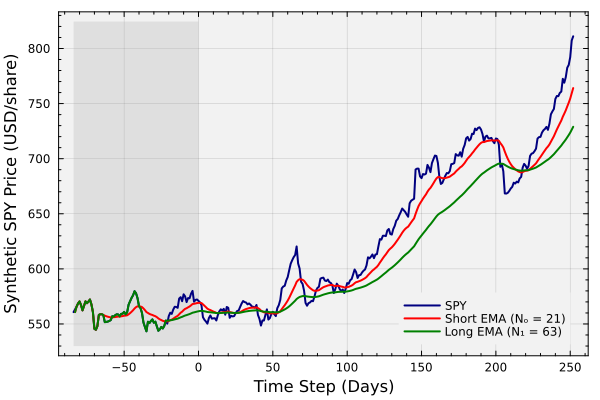

In [20]:
let
    
    # initialize -
    EMA_short = EMA_data.short_term_EMA;
    EMA_long = EMA_data.long_term_EMA;
    offset = Nₒ + N₁; # offset to account for moving average buffer
    
    xvals = S[:,1] .- offset; # shifted time axis
    y_min, y_max = extrema(vcat(S[:,2], EMA_short[:,2], EMA_long[:,2]));
    y_pad = max(0.05 * (y_max - y_min), 1.0e-6);
    y_low = y_min - y_pad;
    y_high = y_max + y_pad;

    # plot with single shaded pre-history block (time < 0) -
    plt = plot(xlabel = "Time Step (Days)", ylabel = "Synthetic SPY Price (USD/share)");
    x_left = minimum(xvals);
    x_right = 0.0;
    plot!(plt, Shape([x_left, x_right, x_right, x_left], [y_low, y_low, y_high, y_high]);
          color = :darkgray, alpha = 0.25, linealpha = 0, label = false);

    plot!(plt, xvals, S[:,2], lw=2, label="SPY", c=:navy);
    plot!(plt, EMA_short[:,1] .- offset, EMA_short[:,2], label = "Short EMA (Nₒ = $Nₒ)", color = :red, xminorticks = true, yminorticks = true, lw=2);
    plot!(plt, EMA_long[:,1] .- offset, EMA_long[:,2], label = "Long EMA (N₁ = $N₁)", color = :green, lw=2);
    plot!(plt, bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);

end


Now that we have the moving averages, let's generate a sentiment signal based upon their difference. 

> __Idea:__
> 
> If the short-term moving average is larger than the long-term moving average, we interpret this as a bullish signal. Conversely, if the short-term moving average is less than the long-term moving average, we interpret this as a bearish signal. If the two averages are equal, we interpret this as a neutral signal. So, let's propose a model of our risk-aversion parameter $\lambda$ based on these signals:
> $$
\begin{align*}
\lambda_{t} &= G\Bigl(\frac{\bar{S}^{(s)}_{t}}{\bar{S}^{(l)}_{t}} - 1\Bigr)\quad{G\in\mathbb{R}_{>0}}\\
\end{align*}
$$
> where $G$ is a scaling (gain) constant, $\bar{S}^{(s)}_{t}$ is the short-term moving average at time $t$, and $\bar{S}^{(l)}_{t}$ is the long-term moving average at time $t$.

Let's compute the time series of risk-aversion parameters based on the moving averages. We'll store the results in the `lambda_series::Vector{Float64}` variable:

In [21]:
lambda_series = let

    # initialize -
    length_of_S = size(S,1); # how may time setps do we have
    lambda_series = Array{Float64,2}(undef, length_of_S, 2);
    EMA_short = EMA_data.short_term_EMA;
    EMA_long = EMA_data.long_term_EMA;

    # compute lambda -
    for t ∈ 1:length_of_S
        
        lambda_series[t,1] = t; # time step
        if t <= offset
            lambda_series[t, 2] = 0.0; # no signal until we have enough data
        else
            λ_t = -GAIN*(EMA_short[t,2] - EMA_long[t,2]) / EMA_long[t,2]; # compute lambda
            lambda_series[t, 2] = λ_t;
        end
    end
    
    lambda_series; # return
end

336×2 Matrix{Float64}:
   1.0   0.0
   2.0   0.0
   3.0   0.0
   4.0   0.0
   5.0   0.0
   6.0   0.0
   7.0   0.0
   8.0   0.0
   9.0   0.0
  10.0   0.0
   ⋮    
 328.0  -0.318777
 329.0  -0.339631
 330.0  -0.353987
 331.0  -0.369537
 332.0  -0.389054
 333.0  -0.407026
 334.0  -0.427201
 335.0  -0.455645
 336.0  -0.482108

Fill me in later.

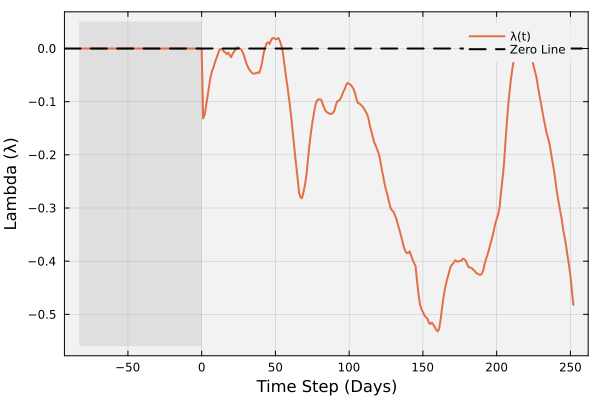

In [22]:
let
    # plot -
    MA_short = EMA_data.short_term_EMA;
    EMA_long = EMA_data.long_term_EMA;
    offset = Nₒ + N₁; # offset to account for moving average buffer

    xvals = lambda_series[:,1] .- offset; # shifted time axis
    y_min, y_max = extrema(lambda_series[:,2]);
    y_pad = max(0.05 * (y_max - y_min), 1.0e-6);
    y_low = y_min - y_pad;
    y_high = y_max + y_pad;
    x_left = minimum(xvals);
    x_right = 0.0;

    plt = plot(xlabel = "Time Step (Days)", ylabel = "Lambda (λ)", bg="gray95", 
        background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topright);
    plot!(plt, Shape([x_left, x_right, x_right, x_left], [y_low, y_low, y_high, y_high]);
          color = :darkgray, alpha = 0.25, linealpha = 0, label = false);
    
    plot!(lambda_series[:,1] .- offset, lambda_series[:,2], xlabel = "Time Step (Days)", lw=2, label="λ(t)");
    hline!([0.0], linestyle = :dash, color = :black, label = "Zero Line", lw=2);
end

Fill me in later.

In [23]:
future_share_price_array = let

    # initialize -
    number_of_time_steps = size(S,1); # number of time steps
    future_share_price_array = Array{Float64,2}(undef, number_of_time_steps, K+1);
    
    for ticker ∈ eachindex(my_list_of_tickers)
    
        ticker_symbol = my_list_of_tickers[ticker];
        sim_params = sim_model_parameters[ticker_symbol];
        αᵢ = sim_params.alpha; # asset i intercept
        βᵢ = sim_params.beta; # asset i sensitivity to market
        TV = sim_params.training_variance; # asset i total variance
        σᵢ = sqrt(Δt*TV); # asset i standard deviation
        Sᵢ = initial_share_price_dict[ticker_symbol]; # initial share price for asset i
        
        
        future_share_price_array[1,1] = 1; # time step
        future_share_price_array[1,ticker+1] = Sᵢ; # initial price
        
        # time-loop -
        for t ∈ 2:number_of_time_steps
            gᵢ = αᵢ + βᵢ*(gₘ[t-1]);
            future_share_price_array[t,1] = t; # time step
            future_share_price_array[t,ticker+1] = future_share_price_array[t-1,ticker+1]*exp(gᵢ*Δt); # compute the next price
        end    
    end
    
    future_share_price_array;
end

336×3 Matrix{Float64}:
   1.0  230.19   415.6
   2.0  232.717  419.994
   3.0  234.228  422.62
   4.0  235.229  424.359
   5.0  233.713  421.717
   6.0  231.454  417.782
   7.0  233.518  421.369
   8.0  235.67   425.109
   9.0  234.947  423.849
  10.0  235.782  425.297
   ⋮             
 328.0  380.345  672.465
 329.0  387.439  684.552
 330.0  385.499  681.238
 331.0  388.634  686.575
 332.0  393.987  695.685
 333.0  395.699  698.594
 334.0  400.12   706.113
 335.0  409.414  721.917
 336.0  411.885  726.111

Fill me in later.

In [24]:
let

    # initialize -
    ticker_to_plot = "AMD";
    ticker_index = findfirst(isequal(ticker_to_plot), my_list_of_tickers);


    plot(future_share_price_array[:,1] .- offset, future_share_price_array[:,ticker_index+1], xlabel = "Time Step (Days)", 
        ylabel = "Synthetic Share Price (USD/share)", legend = false, lw=2, label="$(ticker_to_plot)");

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topright);
end

MethodError: MethodError: no method matching +(::Nothing, ::Int64)
The function `+` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  +(::Any, ::Any, !Matched::Any, !Matched::Any...)
   @ Base operators.jl:642
  +(!Matched::Missing, ::Number)
   @ Base missing.jl:123
  +(!Matched::Complex{Bool}, ::Real)
   @ Base complex.jl:323
  ...


## Task 3: Implement the trade bot loop
Fill me in later.

### Wealth Calculation for a risk-free alternative investment
consider the risk-free STRIPS bond investment. In this case, the initial investment amount will grow at the risk-free rate until maturity. Let's compute the wealth time series for this investment and store it in the `wealth_alternative_investment_STRIPS::Array{Float64,1}` variable:

In [25]:
wealth_alternative_investment_STRIPS = let

    # initialize -
    maximum_number_trading_days = number_of_time_steps = size(S,1) - offset;
    wealth_array = Array{Float64, 1}(undef, maximum_number_trading_days); # preallocate wealth array
    wealth_array[1] = B; # initial wealth is just the initial investment

    for day_index in 2:maximum_number_trading_days

        # compute wealth generated by investing in risk-free STRIPS bond until the end of the investment period
        wealth_generated = B * exp(risk_free_rate * (day_index - 1) * Δt); # wealth generated by STRIPS bond
        wealth_array[day_index] = wealth_generated; # store in array
    end
   
    wealth_array; # return
end;

### Alternative Investment: SPY ETF
Consider an alternative investment in the SPY ETF. In this case, the initial investment amount will grow according to the price changes of the SPY ETF. Let's compute the wealth time series for this investment and store it in the `wealth_alternative_investment_SPY::Array{Float64,1}` variable:

In [26]:
wealth_alternative_investment_SPY = let

    # initialize -
    number_of_time_steps = size(S,1) - offset; # number of time steps
    wealth_array = Array{Float64, 1}(undef, number_of_time_steps); # preallocate wealth array
    initial_SPY_price = S[offset, 2]; # initial SPY price at start of investment
    initial_SPY_shares = B / initial_SPY_price; # number of SPY shares purchased initially
    tradingdayindexvector = range(offset + 1, stop = size(S,1), step = 1) |> collect;

    for day_index ∈ eachindex(tradingdayindexvector)

        i = tradingdayindexvector[day_index];
        current_SPY_price = S[i, 2]; # current SPY price at this time step
        wealth_array[day_index] = initial_SPY_shares * current_SPY_price; # wealth generated by SPY investment
    end

    wealth_array; # return
end;

### What Information Should We Use to Update?
Given that our preference models are risk-aware single index models augmented with ticker-picker preferences, we could do several things here. However, let's update the preference coefficients $\gamma_{i}$ using a new value for the expected market growth rate, which we assume is an exponential moving average (EMA) of the market excess growth rate.

We store the SPY growth rate moving average in the `exponential_moving_average_market_growth::Array{Float64,1}` variable:

In [27]:
exponential_moving_average_market_growth = let

    # initialize -
    α = 2.0 / (N₂ + 1.0); # smoothing factor
    ema_array = Array{Float64,1}(undef, length(gₘ));
    ema_array[1] = gₘ[1]; # initial value

    for t in 2:length(gₘ)
        ema_array[t] = α * gₘ[t] + (1 - α) * ema_array[t-1];
    end

    ema_array; # return
end;

__Visualize:__ Let's plot the actual market excess growth rate alongside the exponential moving average. The smoothed EMA (orange) removes daily noise from market returns (blue), revealing the underlying trend in the market return.

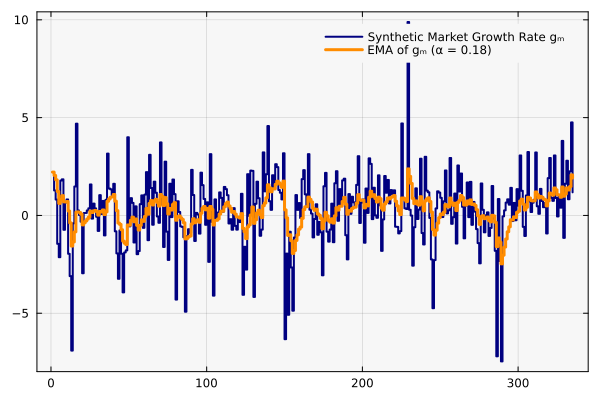

In [28]:
let

    # initialize -
    α = 2.0 / (N₂ + 1.0) |> x-> round(x, digits=2); # smoothing factor

    plot(gₘ, label="Synthetic Market Growth Rate gₘ", lw=2, linecolor=:navy, linetype=:steppost)
    plot!(exponential_moving_average_market_growth, label="EMA of gₘ (α = $α)", lw=3, linecolor=:darkorange, linetype=:steppost)
    plot!(bg="gray97", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
end

Fill me in later.

In [29]:
contextmodel = let

    # Fields required in data NamedTuple:
    # B::Float64 # total budget for investment (in USD)
    # tickers::Array{String,1} # array of ticker symbols
    # marketdata::Array{Float64,2} # market data matrix (rows: time steps, columns: tickers, first column is time)
    # singleindexmodel_parameters::Dict{String, NamedTuple} # single index model parameters for each ticker
    # λ::Float64 # risk aversion parameter
    # Δt::Float64 # time step size (units: years)

    # build the model instance -
    model = build(MySimpleRobotInvestorContextModel, (
        B = B,
        tickers = my_list_of_tickers,
        marketdata = future_share_price_array,
        marketfactor = exponential_moving_average_market_growth,
        singleindexmodel_parameters = sim_model_parameters,
        λ = λ,
        Δt = Δt,
    ));

    model;
end

MySimpleRobotInvestorContextModel(1000.0, ["AAPL", "MSFT"], [2.2140678565154, 2.04363012962892, 1.819554095044378, 1.2245687863006633, 0.6133040290693077, 0.8260382043521193, 1.0115474236203053, 0.6937615911243808, 0.687536692755368, 0.7109892795245782  …  1.0483060022741013, 0.9295751452879965, 1.4532777511049928, 0.9803077482419235, 1.0966423008545918, 1.4057482468001754, 1.3003590283845057, 1.473947989420917, 2.0705250919384017, 1.9086939518407486], [1.0 230.19 415.6; 2.0 232.7166281836726 419.99439545192746; … ; 335.0 409.4142788361169 721.9169370243126; 336.0 411.88502860994913 726.1111073637067], Dict{String, NamedTuple}("EMR" => (ticker = "EMR", n = 2766, p = 2, t = 1.96, alpha = -0.07665207950524315, beta = 1.2198087181256778, alpha_SE = 0.05284125702508786, beta_SE = 0.024609239685084817, alpha_95_CI_lower = -0.18022094327441535, alpha_95_CI_upper = 0.026916784263929044, beta_95_CI_lower = 1.1715746083429115, beta_95_CI_upper = 1.2680428279084441, training_variance = 1941.4996

There are few ways to implement this strategy, we'll do the following:

> __Rebalancing Implementation:__ At each trading day $i$, if $a_{i} = 1$, we liquidate the current portfolio at the open. We assume that we get the open price for each asset on that day. We then recompute the optimal number of shares (where we now update the $\gamma_{i}$ coefficients based on the latest market information and ticker-picker preferences) and purchase those shares at a random price during that trading day (between the open and close). If $a_{i} = 0$, we hold the current portfolio allocation.

Let's set a value for the reallocation vector $\mathbf{a}$:

In [30]:
a = let

    # initialize -
    number_of_time_steps = size(S,1); # number of time steps
    a = ones(Int,number_of_time_steps - offset); # Case: we reallocate daily
    #a = zeros(maximum_number_trading_days); # Case: we *never* reallocate

    # return -
    a;
end;

Fill me in

In [31]:
tradebot_results_dictionary = let

    # initialize -
    tradebot_results_dictionary = Dict{Int64, NamedTuple}();
    number_of_time_steps = size(S,1) - offset; # number of time steps
    tradingdayindexvector = range(offset + 1, stop = size(S,1), step = 1) |> collect;

    # setup initial portfolio (at first trading day) -
    tradebot_results_dictionary[0] = shares(offset, contextmodel); # initial portfolio

    for day_index ∈ eachindex(tradingdayindexvector)
        actual_trading_day_index = tradingdayindexvector[day_index];
        action = a[day_index]; # get the action for this trading day
        
        if (action == 1)
            
            # if we get here, then we are reallocating on this trading day
            mycontextmodel = deepcopy(contextmodel); # make a copy of the context model to modify
            λᵢ = lambda_series[actual_trading_day_index, 2]; # get lambda for this trading day
            cash = tradebot_results_dictionary[day_index - 1].cash; # cash leftover from previous portfolio
            nₒ = tradebot_results_dictionary[day_index - 1].shares; # number of shares of each asset in previous portfolio
            total_wealth_previous_day = 0.0;
            for i ∈ eachindex(nₒ)
                price_at_day = future_share_price_array[actual_trading_day_index - 1, i + 1]; # price of asset i at open
                total_wealth_previous_day += nₒ[i] * price_at_day; # compute total wealth from previous portfolio
            end

            mycontextmodel.B = cash + total_wealth_previous_day; # update budget
            mycontextmodel.λ = λᵢ; # update risk-aversion parameter
            tradebot_results_dictionary[day_index] = shares(actual_trading_day_index, mycontextmodel); # compute new portfolio
        else

            # if we get here, then we are NOT reallocating on this trading day
            tradebot_results_dictionary[day_index] = tradebot_results_dictionary[day_index-1]; # carry over previous day's results
        end
    end
    
    tradebot_results_dictionary # return
end;

### Wealth Calculation for the Tradebot
Let's compute the wealth generated by the dynamic reallocation strategy. For each trading day, track positions and values based on the reallocation results. On days without reallocation, carry forward the previous portfolio; on reallocation days, use the new portfolio weights computed from updated market information and preferences.

We store the wealth in the `wealth_array_tradebot::Array{Float64,2}` where each row is a day. The columns are given by:
* Columns $i=1\;\text{to}\;K$: These columns hold the value associated with our position in ticker $i$. If we don't hold ticker $i$, then this entry will be `0`. 
* Column $K+1$: This column holds the total value of all shares in the portfolio (valued at the close price for the day).
* Column $K+2$: This column holds the cash on hand (cash from share sales or unallocated capital).
* Column $K+3$: The total value of the portfolio (liquidation value plus cash on hand).

Construct the wealth array for this case:

In [32]:
wealth_array_tradebot = let

    # initialize -
    my_portfolio_tickers = contextmodel.tickers;
    number_of_tickers_in_portfolio = length(my_portfolio_tickers);
    number_of_time_steps = size(S,1) - offset; # number of time steps
    tradingdayindexvector = range(offset + 1, stop = size(S,1), step = 1) |> collect;
    wealth_array = Array{Float64,2}(undef, number_of_time_steps, number_of_tickers_in_portfolio+3); # final column is total wealth
    
    # let's initialize our wealth at day 1 (given where we purchased the shares)
    for ticker ∈ eachindex(my_portfolio_tickers)
        n_shares = tradebot_results_dictionary[0].shares[ticker];
        price_at_purchase = tradebot_results_dictionary[0].price[ticker];
        wealth_array[1, ticker] = n_shares * price_at_purchase;
    end
    wealth_array[1, end-2] = sum(wealth_array[1, 1:end-3]); # total value of shares at day 1
    wealth_array[1, end-1] = tradebot_results_dictionary[0].cash; # cash leftover at day 1
    wealth_array[1, end] = sum(wealth_array[1, (end-2):(end-1)]); # total wealth at day 1

    # fill in the remaining days
    for day_index ∈ eachindex(tradingdayindexvector)
        actual_day_index = tradingdayindexvector[day_index];
        results_of_day = tradebot_results_dictionary[day_index];
        for ticker ∈ eachindex(my_portfolio_tickers)
            n_shares = results_of_day.shares[ticker];
            price_at_day = future_share_price_array[actual_day_index - 1, ticker+1];
            wealth_array[day_index, ticker] = n_shares * price_at_day;
        end
        wealth_array[day_index, end-2] = sum(wealth_array[day_index, 1:end-3]); # total value of shares at this day
        wealth_array[day_index, end-1] = results_of_day.cash; # cash leftover at this day
        wealth_array[day_index, end] = sum(wealth_array[day_index, (end-2):(end-1)]); # total wealth at this day
    end    

    wealth_array; # return
end;

In [33]:
wealth_array_tradebot

252×5 Matrix{Float64}:
    0.0      0.0      0.0   1000.0          1000.0
    0.0      0.0      0.0   1000.0          1000.0
    0.0      0.0      0.0   1000.0          1000.0
    0.0      0.0      0.0   1000.0          1000.0
    0.0      0.0      0.0   1000.0          1000.0
    0.0      0.0      0.0   1000.0          1000.0
    0.0      0.0      0.0   1000.0          1000.0
    0.0      0.0      0.0   1000.0          1000.0
    0.0      0.0      0.0   1000.0          1000.0
    0.0      0.0      0.0   1000.0          1000.0
    ⋮                                       
 2167.8   1954.96  4122.75     4.54747e-13  4122.75
 1897.86  1809.54  3707.4      0.0          3707.4
 2045.47  1821.5   3866.97     4.54747e-13  3866.97
 1680.39  1861.15  3541.54    -4.54747e-13  3541.54
 1694.0   1529.39  3223.39     4.54747e-13  3223.39
 1781.81  1449.92  3231.73     0.0          3231.73
 1901.02  1762.5   3663.52     0.0          3663.52
 2239.1   1811.48  4050.58     0.0          4050.58
 2177.0

__Visualize:__ Compare portfolio wealth trajectories across all strategies over the full investment period.

> __What do we expect?__ Daily reallocation __may__ provide more responsiveness to market changes than buy-and-hold, but the magnitude of improvement depends on market regime and reallocation effectiveness. If markets are trending (strongly up or down), buy-and-hold may outperform due to lower transaction sensitivity. In volatile or mean-reverting markets, reallocation can capture opportunities missed by static positioning.

> __Color Legend:__
> * **Orange:** Bandit daily reallocation, adjusts positions each reallocation day (controlled using the $\mathbf{a}$ vector)
> * **Red:** S&P 500 ETF (SPY) passive market index. This serves as a benchmark for overall market performance.
> * **Green:** Risk-free STRIPS bond. This is the risk-free benchmark.

Do we see an improvement with reallocation?

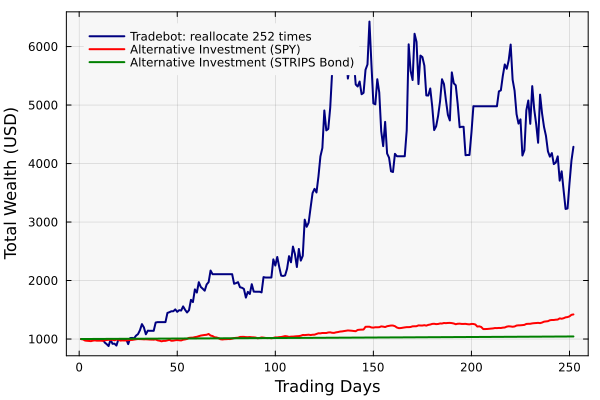

In [34]:
let

    plot(wealth_array_tradebot[:, end],
        xlabel = "Trading Days",
        ylabel = "Total Wealth (USD)",
        label = "Tradebot: reallocate $(length(a[a .== 1])) times",
        lw = 2,
        linecolor = :navy,
    );

    plot!(wealth_alternative_investment_SPY,
        label = "Alternative Investment (SPY)",
        linecolor = :red,   
        lw = 2,
    );

    plot!(wealth_alternative_investment_STRIPS,
        label = "Alternative Investment (STRIPS Bond)",
        linecolor = :green,   
        lw = 2,
    );

    plot!(bg="gray97", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
end

## Summary
One direct summary sentence goes here. 

> __Key Takeaways:__
> 
> Three key takeaways go here.

One direct conclusion sentence goes here.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___